*Notebook for learning JAX-MD and documenting observations.*

### Demo

The following code goes through the [JAX MD demo](https://colab.research.google.com/github/google/jax-md/blob/main/notebooks/talk_demo.ipynb).

#### Potential

In [1]:
# creating a soft-sphere potential
import jax.numpy as jnp

def soft_sphere(r):
    return jnp.where(
        r < 1.0,
        1/3 * (1 - r)**3,
        0.0
    )

print("Soft-sphere potential (r = 0.5):", soft_sphere(0.5))

Soft-sphere potential (r = 0.5): 0.041666668


Text(0, 0.5, 'V(r)')

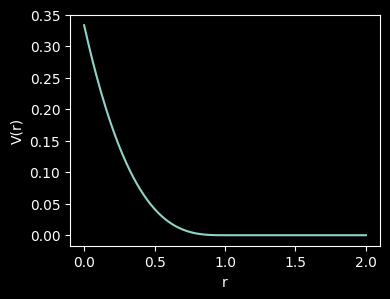

In [3]:
# plot of soft-sphere potential
import matplotlib.pyplot as plt
plt.style.use('dark_background')    # replace 'dark_background' with 'default' for light theme
plt.rcParams['figure.figsize'] = [4, 3]

r_series = jnp.linspace(0, 2.0, 200)
plt.plot(r_series, soft_sphere(r_series))

plt.xlabel("r")
plt.ylabel("V(r)")

In [4]:
from jax import grad

dv_dr = grad(soft_sphere)   # gradient of soft-sphere potential

print("Gradient of soft-sphere potential (r = 0.5):", dv_dr(0.5))

Gradient of soft-sphere potential (r = 0.5): -0.25


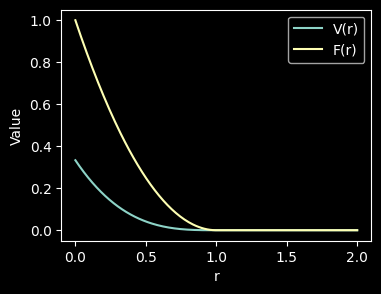

In [5]:
# we cannot implement dv_dr(r_series) directly because grad only works on scalar inputs
# so we use vmap to vectorize the gradient function
from jax import vmap

dv_dr_vec = vmap(dv_dr)

plt.plot(r_series, soft_sphere(r_series), label="V(r)")
plt.plot(r_series, -dv_dr_vec(r_series), label="F(r)")
plt.xlabel("r")
plt.ylabel("Value")
plt.legend()

#### System Initialization

In [6]:
from jax import random

key = random.PRNGKey(0)

num_particles = 128     # number of particles
dim = 2                 # 2D system

In [28]:
from jax_md.quantity import box_size_at_number_density

# number_density = N / V
box_size = box_size_at_number_density(particle_count = num_particles,
                                      number_density = 1.2,
                                      spatial_dimension = dim)

print("Box size:", box_size)                                    # calculates box size for a given desired number density of particles

R = random.uniform(key, (num_particles, dim), maxval=box_size)  # random initial positions of particles within the box

Box size: 10.327955


I think that Plotly might be a more interesting approach to visualizing our dynamics, and might be better for the long run, since it doesn't seem that JAX MD has a really good way of visualizing the dynamics if you're not using Colab. Plotly is interesting enough to learn, anyways, so I think it's worth the small time investment.

#### Plotly Digression

In [29]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

In [31]:
def plot_disks(R, radius=0.5, box_size=1.0, width=600, height=600):
    fig = go.Figure()

    # Add each circle as a shape
    for (x, y) in R:
        fig.add_shape(
            type="circle",
            x0=x - radius, x1=x + radius,
            y0=y - radius, y1=y + radius,
            line=dict(width=0),
            fillcolor="lightblue",
            opacity=0.8
        )

    # Set view box
    view_box_delta = 0.05 * box_size
    fig.update_xaxes(range=[0 - view_box_delta, box_size + view_box_delta], scaleanchor="y", scaleratio=1, title="x")
    fig.update_yaxes(range=[0 - view_box_delta, box_size + view_box_delta], title="y")

    fig.update_layout(width=width, height=height, template="plotly_dark", title={
        "text": "Particle Positions",
        "x": 0.5,
        "xanchor": "center"
    })
    fig.show()

# Example
# R is an (N,2) array of positions
# box_size = 10.0
plot_disks(R, radius=0.5, box_size=box_size)


##### Controllable Animation of a Single Moving Circle

In [70]:
# --- path of the circle ---
T = 600
t = np.linspace(0, 2*np.pi, T)
x_path = 5 + 3*np.cos(t)
y_path = 5 + 2*np.sin(t)
radius = 0.3
box_size = 10

# --- create figure ---
fig = go.Figure()

# initial shape
fig.add_shape(
    type="circle",
    x0=x_path[0]-radius, x1=x_path[0]+radius,
    y0=y_path[0]-radius, y1=y_path[0]+radius,
    line=dict(width=0),
    fillcolor="lightblue",
    opacity=0.8
)

# --- frames ---
frames = []
for i in range(T):
    frames.append(
        go.Frame(
            layout=dict(
                shapes=[
                    dict(
                        type="circle",
                        x0=x_path[i]-radius, x1=x_path[i]+radius,
                        y0=y_path[i]-radius, y1=y_path[i]+radius,
                        line=dict(width=0),
                        fillcolor="lightblue",
                        opacity=0.8
                    )
                ]
            ),
            name=str(i)
        )
    )
fig.frames = frames

# --- axes and layout ---
fig.update_xaxes(range=[0, box_size], scaleanchor="y", scaleratio=1)
fig.update_yaxes(range=[0, box_size])
fig.update_layout(
    width=600, height=600,
    title={"text": "Moving Circle with Shapes", "x":0.5, "xanchor":"center"}
)

# --- slider ---
fig.update_layout(
    sliders=[{
        "steps": [
            {
                "args": [[str(i)], {"frame": {"duration": 50}, "mode": "immediate"}],
                "label": str(i),
                "method": "animate"
            }
            for i in range(T)
        ],
        "transition": {"duration": 0},
        "x": 0.1, "len": 0.8,
    }]
)

# --- vertical stacked buttons ---
fig.update_layout(
    template='plotly_dark',
    updatemenus=[{
        "type": "buttons",
        "direction": "down",
        "x": 1.05, "y": 0.8,
        "showactive": False,
        "xanchor": "left", "yanchor": "top",
        "bgcolor": "rgba(50,50,50,0.8)",    # semi-transparent dark gray
        "bordercolor": "white",               # white border
        "font": {"color": "white"},           # text color
        "buttons": [
            {
                "label": "▶ Play",
                "method": "animate",
                "args": [None, {"frame": {"duration": 50, "redraw": True}, 
                                "fromcurrent": True,
                                "mode": "immediate"}]
            },
            {
                "label": "⏸ Pause",
                "method": "animate",
                "args": [[None], {"frame": {"duration": 0}, "mode": "immediate"}]
            }
        ]
    }]
)

fig.show()


### Cookbook

The following code goes through the [JAX MD cookbook](https://colab.research.google.com/github/google/jax-md/blob/main/notebooks/jax_md_cookbook.ipynb).

In [1]:
# write something